In [1]:
import sys
from pathlib import Path
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *

In [ ]:
s = Simulation()
# # compute heff without pulse modulation for parameters
# heff_plain = s.heff(wd, amp)
# Delta = heff_plain[1][1] - 2 * heff_plain[2][2]
# lambda1 = heff_plain[0][1]
# lam = sbc/sab
# delta_detune = 0
# epsilonx, epsilony = pulse_functions_gauss(tg, Delta, delta_detune, sigma_ratio = sigma)
# amp_modulated = lambda t: (epsilonx(t)/2 + 1j * epsilony(t)/2) / sab
# heff_modulated = lambda t, args=None: s.heff(wd, amp_modulated(t))
# def heff_modulated_gauge(t, args=None):
#     heff_mod = heff_modulated(t)
#     return Qobj(heff_mod - [[heff_mod[0,0],0,0],[0,heff_mod[0,0],0],[0,0,heff_mod[0,0]]])
tlist = np.linspace(0, tg, 200)

Generate a resonant hamiltonian to get Delta from this

In [4]:
# select a typical amp
amp = 0.2 * 2*np.pi
wd = s.find_resonance(amp)
heff = s.heff(wd, amp)
Delta = abs(heff[2][2] - heff[0][0])
lambda_param = heff[1][2]/heff[0][1]
lambda_param, Delta, wd/(2*np.pi), heff

(np.complex128(9.9046786357596+0j),
 np.float64(1.1669162348511566),
 np.float64(0.7061797946700356),
 array([[-0.00128773+0.j,  0.01338727+0.j, -0.00875968+0.j],
        [ 0.01338727+0.j, -0.00128773+0.j,  0.13259658+0.j],
        [-0.00875968+0.j,  0.13259658+0.j, -1.16820397+0.j]]))

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


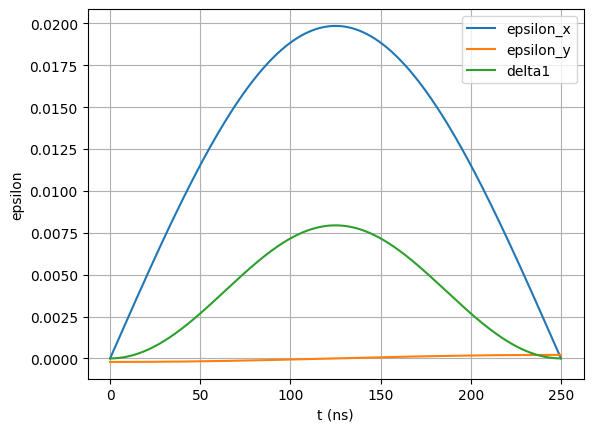

In [5]:
tg_test = 250
t_test_list = np.linspace(0, 250, 5000)
_, epsilonx, epsilony, delta1 = h_target(Delta, lambda_param, tg_test)

ex = np.array([epsilonx(t) for t in t_test_list])
ey = np.array([epsilony(t) for t in t_test_list])
d1 = np.array([delta1(t) for t in t_test_list])
plt.figure()
plt.plot(t_test_list, ex, label='epsilon_x')
plt.plot(t_test_list, ey, label='epsilon_y')
plt.plot(t_test_list, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg):
    tlist = np.linspace(0, tg, 5000)
    amp, wd = compute_cos_params(s, tg)
    heff0 = s.heff(wd, 0)
    # with the right amplitude for the given gate time, we can compute parameters from heff
    heff_params = s.heff(wd, amp)
    Delta = abs(heff_params[2][2] - heff_params[0][0]) 
    # rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
    rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case
    # with all parameters set we can compute the target hamiltonian
    ht, _,_,_ = h_target(Delta, rrr, tg)
    return ht, tlist, heff0, wd, amp
ht, tlist, heff0, wd, amp = compute_htarget(200)

In [18]:
# target hamiltonian- fidelity
fid_t = extract_pop_fid(ht, tlist)['iswap_fidelity']
print(f"{(1-fid_t):.1e}")

2.0e-06


To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


100%|██████████| 10/10 [00:22<00:00,  2.26s/it]


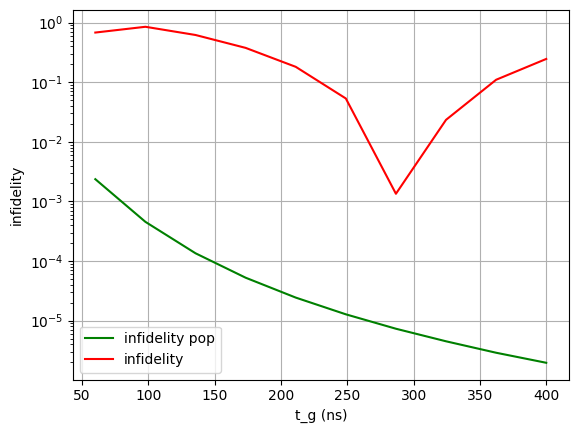

In [ ]:
lf_pop = []
lf = []
ltg = np.linspace(60, 400, 10)
for tg in tqdm(ltg):
    ht, tlist, _,_ = compute_htarget(tg)
    f = extract_fidelity(ht, tlist)
    fpop = extract_pop_fid(ht, tlist)['iswap_fidelity']
    # print("1-p: ", (1-f), " tg: ", tg)
    lf_pop.append(1-fpop)
    lf.append(1-f)
ax = plt.subplot()
plt.plot(ltg, lf_pop, label='infidelity pop', color='green')
plt.plot(ltg, lf, label='infidelity', color='red')
plt.xlabel('t_g (ns)')
plt.ylabel('infidelity')
ax.set_yscale('log')
plt.legend()
plt.grid(True)
plt.show()


After verifying the fidelity of the target-hamiltonian, now the target hamiltonian must be achieved by a given time-dependant pulse-shape that is applied to the coupler

In [ ]:
# parameters like lambda can be computed via the effective hamiltonian with normal drive
def find_parameter_change(wd0, heff0, heff_t):
    # the interesting magnitudes are delta_difference and the rabi rate
    dd0 = heff0[0][0] - heff0[1][1]
    ddt = heff_t[0][0] - heff_t[1][1]
    r0 = heff[0][1]
    rt = heff_t[0][1]
    D_delta = ddt - dd0
    D_Omega = rt - r0
    # get the matrix of derivatives
    dw_delta = partial_derivative_heff_element(s, 0,0,0,wd0,'wd') - partial_derivative_heff_element(s, 1,1,0,wd0,'wd')
    da_delta = (partial_derivative_heff_element(s, 0,0,0,wd0,'amp_real') - partial_derivative_heff_element(s, 1,1,0,wd0,'amp_real') 
                + 1j*(partial_derivative_heff_element(s, 0,0,0,wd0,'amp_imag') - partial_derivative_heff_element(s, 1,1,0,wd0,'amp_imag')))
    dw_Omega = partial_derivative_heff_element(s, 0,1,0,wd0,'wd')
    da_Omega = partial_derivative_heff_element(s, 0,1,0,wd0,'amp_real') - 1j*partial_derivative_heff_element(s, 0,1,0,wd0,'amp_imag')
    W = np.array([[dw_delta, da_delta], [dw_Omega, da_Omega]], dtype=complex)
    W_invers = np.linalg.inv(W)
    dw, da = np.multiply(W_invers, np.array([D_delta, D_Omega], dtype=complex))
    return dw, da

In [ ]:
dw, da = find_parameter_change()

for tg in tqdm(ltg):
    ht, tlist, _ = compute_htarget(tg)
    f = extract_fidelity(ht, tlist)
    fpop = extract_pop_fid(ht, tlist)['iswap_fidelity']
    # print("1-p: ", (1-f), " tg: ", tg)
    lf_pop.append(1-fpop)
    lf.append(1-f)

In [ ]:
# from the engineered hamiltonain compute also the fidelity and check if the epsilonx epsilony values are correct
heff_0 = s.heff(wd, 0)
h_engineered = compute_t_dependency(s, heff_0, tg)

fidelity_engineered = s.extract_fidelity(h_engineered, tlist)
print(f"fid_engineered: {fidelity_engineered:6f}")
# test wether the fidelity problem might have something to do with the different mesolve input
def fpop(t, args=None):
    h_engineered_combined = h_engineered[0]
    for coeff, func in h_engineered[1:]:
        h_engineered_combined += coeff * func(t, args)
    return h_engineered_combined
def heff_linear_app(t, args=None):
    h_engineered = fpop(t,args)
    parameter_change = find_parameter_change(amp, wd, Qobj(heff_0), h_engineered)
    print("plain")
    display(Qobj(heff_0))
    print("engineered")
    display(h_engineered)
    damp = parameter_change[0]
    dwd = parameter_change[1]
    print("damp: ", damp)
    print("dwd: ", dwd)
    print()
    return Qobj(s.heff(wd + dwd, amp + damp))
# make a test run for one time
test_t = tlist[int(len(tlist)/2)]
heff_linear_app(test_t)


TypeError: compute_t_dependency() takes 2 positional arguments but 3 were given

In [ ]:
# test the fidelity of the defined function 
# s.extract_fidelity([heff_linear_app], tlist)

In [ ]:
# engineer a hmilatonian that has constant diagonal elements to check if the diagonal signal kills the fidelity
def heff_diag_engineered(t, args=None):
    h_mod_g = heff_modulated_gauge(t, args)
    delta0 = heff_plain[0][0]
    h_mod_g[1][1] = heff_plain[1][1] - delta0
    h_mod_g[2][2] = heff_plain[2][2] - delta0
    h_mod_g[0][2] = 0
    h_mod_g[2][0] = 0
    return Qobj(h_mod_g)
# fid_test = s.extract_fidelity([heff_diag_engineered], tlist)
# print(f"fid_test: {fid_test:6f}")